In [231]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

In [138]:
paths = ["raw//"+ x for x in os.listdir("raw") if x.endswith('.csv')]

In [139]:
import os

print(os.getcwd())
for p in paths:
    print(p, "->", os.path.exists(p))


c:\Users\mohak\OneDrive\Documents\DATASET\Network_Anomaly_Detection_CICIDS2017
raw//Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv -> True
raw//Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv -> True
raw//Friday-WorkingHours-Morning.pcap_ISCX.csv -> True
raw//Monday-WorkingHours.pcap_ISCX.csv -> True
raw//Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv -> True
raw//Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv -> True
raw//Tuesday-WorkingHours.pcap_ISCX.csv -> True
raw//Wednesday-workingHours.pcap_ISCX.csv -> True


In [140]:
paths


['raw//Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
 'raw//Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
 'raw//Friday-WorkingHours-Morning.pcap_ISCX.csv',
 'raw//Monday-WorkingHours.pcap_ISCX.csv',
 'raw//Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
 'raw//Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
 'raw//Tuesday-WorkingHours.pcap_ISCX.csv',
 'raw//Wednesday-workingHours.pcap_ISCX.csv']

In [141]:
test_path = paths[:3]
train_path = ['raw//Monday-WorkingHours.pcap_ISCX.csv',
             'raw//Tuesday-WorkingHours.pcap_ISCX.csv',
             'raw//Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
             'raw//Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
             'raw//Wednesday-workingHours.pcap_ISCX.csv']
test_path = test_path[::-1]
test_path

['raw//Friday-WorkingHours-Morning.pcap_ISCX.csv',
 'raw//Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
 'raw//Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv']

In [142]:
columns_list = [pd.read_csv(p,nrows=0).columns.to_list() for p in paths]
  
all_same = all(cols == columns_list[0] for cols in columns_list)
print("All datasets have matching columns:", all_same)

All datasets have matching columns: True


In [143]:
dfs=[pd.read_csv(p) for p in train_path]

merged_df_train = pd.concat(dfs,axis=0,ignore_index=True) 


dfs=[pd.read_csv(p) for p in test_path]

merged_df_test = pd.concat(dfs,axis=0,ignore_index=True) 
print(len(merged_df_train)+len(merged_df_test))

#total should be 2830743 rows

2830743


In [144]:
merged_df_test.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [145]:
# merged_df_test = merged_df_test.drop([' Destination Port'],axis=1)
# merged_df_train = merged_df_train.drop([' Destination Port'],axis=1)

In [146]:
merged_df_train[' Label'].value_counts()

 Label
BENIGN                        1858775
DoS Hulk                       231073
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Combining Exteremely Small Classes into 1

In [147]:
SMALL_ATTACKS = [
    'Infiltration',
    'Heartbleed'
]

NEW_LABEL = "Other Attacks"
merged_df_train[' Label'] = merged_df_train[' Label'].replace(SMALL_ATTACKS, NEW_LABEL)

Fixing encoding Issues

In [148]:
import re

def clean_web_attack_labels(df):
    
    # 1. Clean 'Web Attack - Brute Force'
    df[' Label'] = df[' Label'].str.replace(
        r'^Web Attack.*Brute Force$', 
        'Web Attack - Brute Force', 
        regex=True
    )

    # 2. Clean 'Web Attack - XSS'
    df[' Label'] = df[' Label'].str.replace(
        r'^Web Attack.*XSS$', 
        'Web Attack - XSS', 
        regex=True
    )
    
    # 3. Clean 'Web Attack - Sql Injection'
    df[' Label'] = df[' Label'].str.replace(
        r'^Web Attack.*Sql Injection$', 
        'Web Attack - Sql Injection', 
        regex=True
    )
    
    return df

merged_df_train = clean_web_attack_labels(merged_df_train.copy())

In [149]:
train_unique_attacks = merged_df_train[' Label'].value_counts().tolist()
train_unique_attacks_names = merged_df_train[' Label'].value_counts().index
test_unique_attacks = merged_df_test[' Label'].value_counts().tolist()
test_unique_attacks_names = merged_df_test[' Label'].value_counts().index

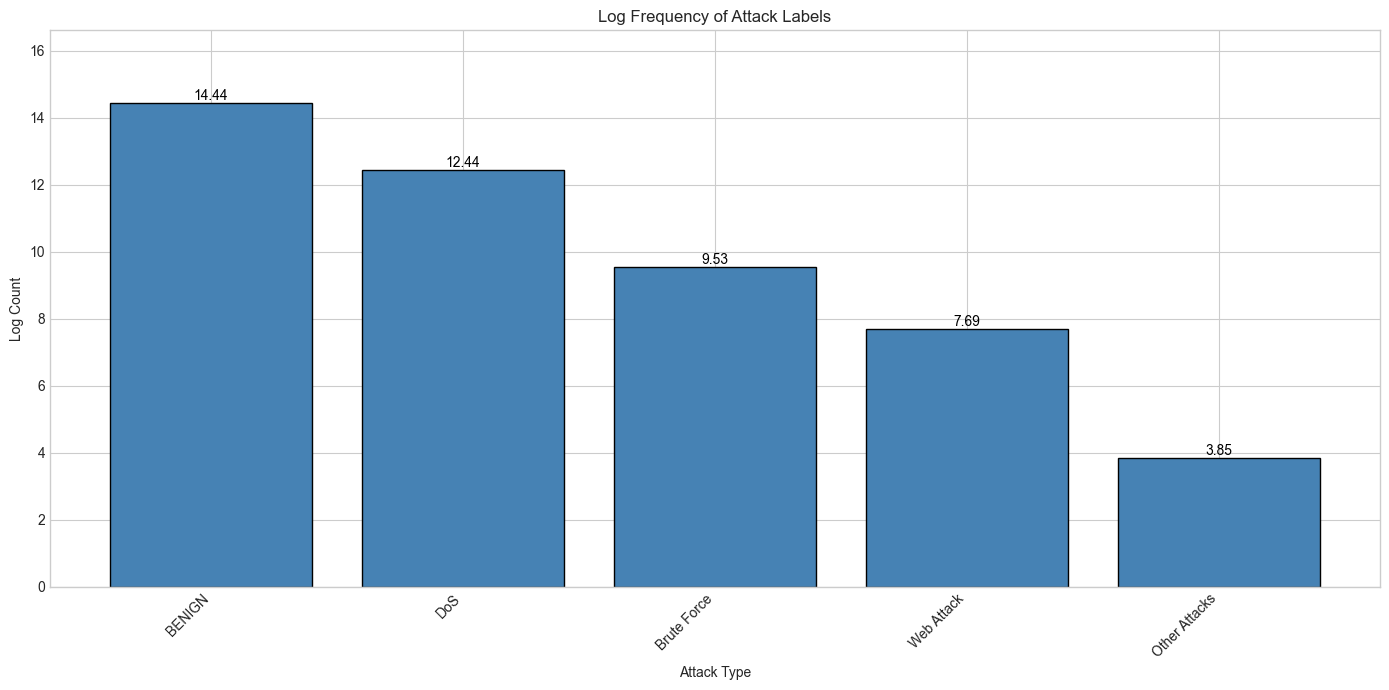

In [162]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(14, 7))
bars = plt.bar(
    train_unique_attacks_names,
    np.log(train_unique_attacks),
    color="steelblue",
    edgecolor="black"
)

for bar, value in zip(bars, np.log(train_unique_attacks)):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title("Log Frequency of Attack Labels")
plt.xlabel("Attack Type")
plt.ylabel("Log Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
ymax = max(np.log(train_unique_attacks))
plt.ylim(0, ymax * 1.15) 
plt.show()


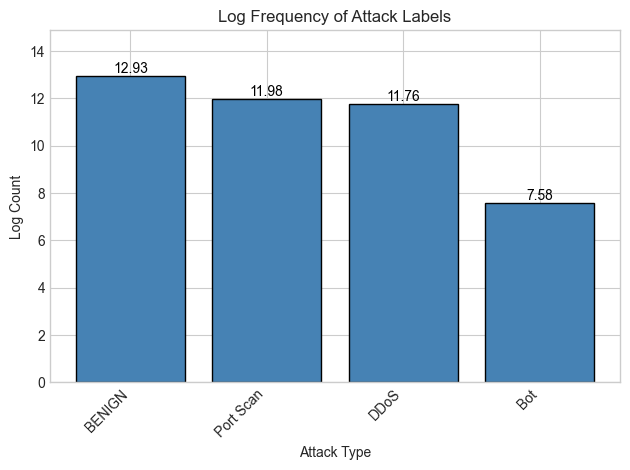

In [163]:
bars = plt.bar(
    test_unique_attacks_names,
    np.log(test_unique_attacks),
    color="steelblue",
    edgecolor="black"
)

for bar, value in zip(bars, np.log(test_unique_attacks)):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title("Log Frequency of Attack Labels")
plt.xlabel("Attack Type")
plt.ylabel("Log Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
ymax = max(np.log(test_unique_attacks))
plt.ylim(0, ymax * 1.15) 
plt.show()

Removing Whitespace in the front

In [152]:
col_names_train = {col: col.strip() for col in merged_df_train.columns}
merged_df_train.rename(columns = col_names_train, inplace = True)
col_names_test = {col: col.strip() for col in merged_df_test.columns}
merged_df_test.rename(columns = col_names_test, inplace = True)

In [153]:
merged_df_train['Label'].value_counts()

Label
BENIGN                        1858775
DoS Hulk                       231073
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Other Attacks                      47
Web Attack - Sql Injection         21
Name: count, dtype: int64

In [154]:
merged_df_test['Label'].value_counts()

Label
BENIGN      414322
PortScan    158930
DDoS        128027
Bot           1966
Name: count, dtype: int64

Mapping labels to Attacks

In [155]:
attack_type_train = {
    'BENIGN': 'BENIGN',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'DoS Hulk': 'DoS',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Web Attack - Brute Force': 'Web Attack',
    'Web Attack - XSS': 'Web Attack',
    'Web Attack - Sql Injection': 'Web Attack',
    'Other Attacks': 'Other Attacks'
}

attack_type_test={
    'DDoS': 'DDoS',
    'PortScan': 'Port Scan',
    'BENIGN': 'BENIGN',
    'Bot': 'Bot',
}
merged_df_test['Attack'] = merged_df_test['Label'].map(attack_type_test)
merged_df_train['Attack'] = merged_df_train['Label'].map(attack_type_train)

In [156]:
merged_df_train['Attack'].value_counts()

Attack
BENIGN           1858775
DoS               252661
Brute Force        13835
Web Attack          2180
Other Attacks         47
Name: count, dtype: int64

In [157]:
merged_df_test['Attack'].value_counts()

Attack
BENIGN       414322
Port Scan    158930
DDoS         128027
Bot            1966
Name: count, dtype: int64

In [158]:
train_unique_attacks = merged_df_train['Attack'].value_counts().tolist()
train_unique_attacks_names = merged_df_train['Attack'].value_counts().index
test_unique_attacks = merged_df_test['Attack'].value_counts().tolist()
test_unique_attacks_names = merged_df_test['Attack'].value_counts().index

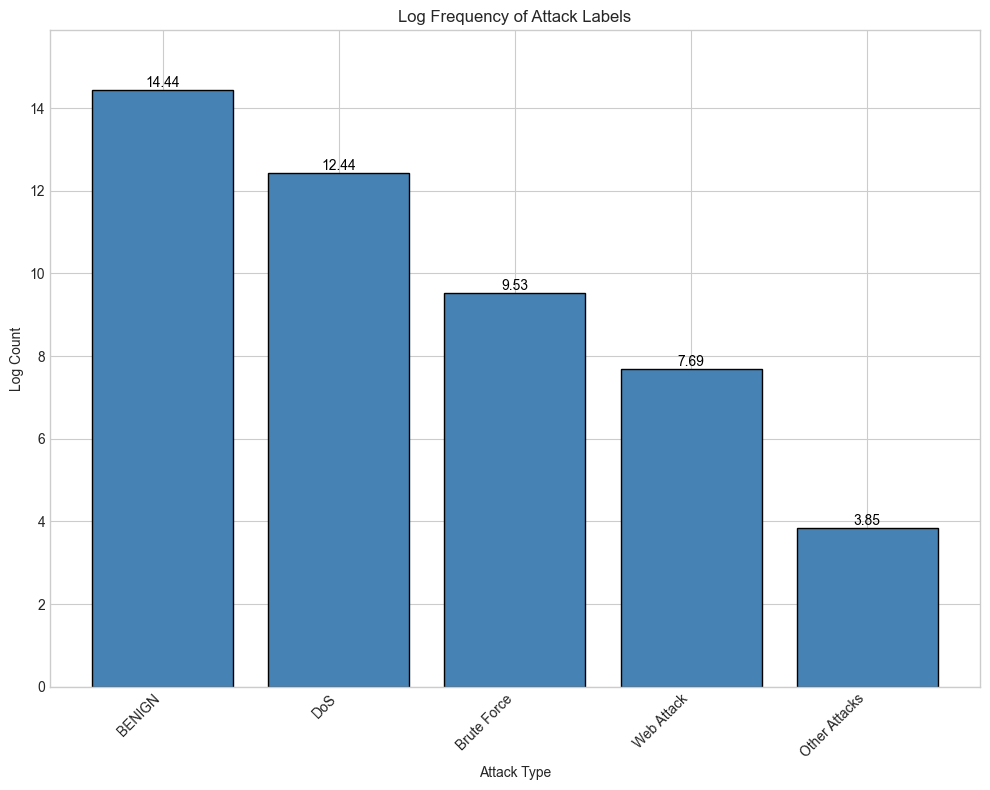

In [ ]:
plt.figure(figsize=(10, 8))

bars = plt.bar(
    train_unique_attacks_names,
    np.log(train_unique_attacks),
    color="steelblue",
    edgecolor="black"
)

for bar, value in zip(bars, np.log(train_unique_attacks)):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title("Log Frequency of Attack Labels")
plt.xlabel("Attack Type")
plt.ylabel("Log Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
ymax = max(np.log(train_unique_attacks))
plt.ylim(0, ymax * 1.15) 
plt.show()

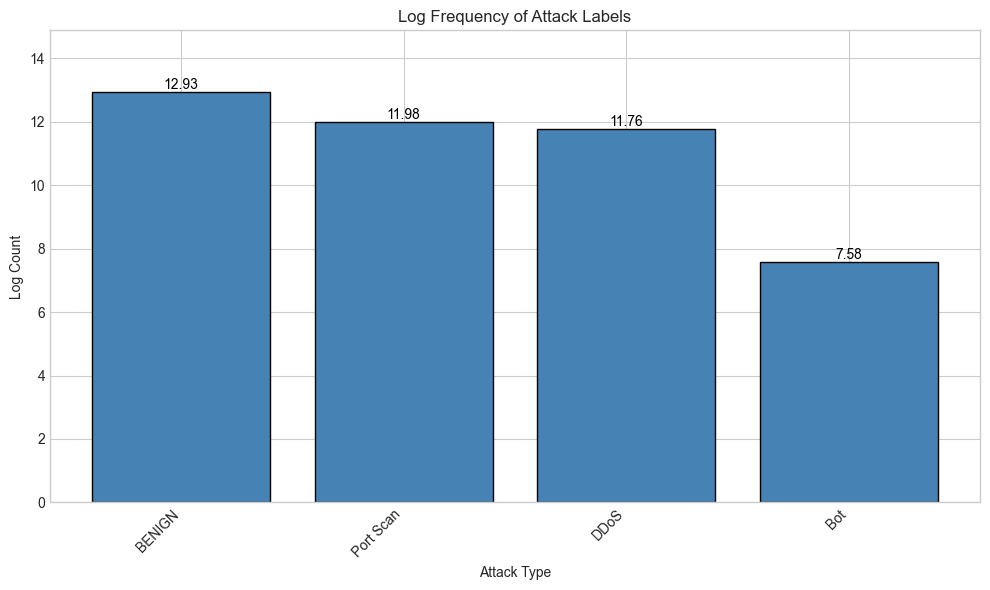

In [165]:
plt.figure(figsize=(10, 6))
bars = plt.bar(
    test_unique_attacks_names,
    np.log(test_unique_attacks),
    color="steelblue",
    edgecolor="black"
)

for bar, value in zip(bars, np.log(test_unique_attacks)):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title("Log Frequency of Attack Labels")
plt.xlabel("Attack Type")
plt.ylabel("Log Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
ymax = max(np.log(test_unique_attacks))
plt.ylim(0, ymax * 1.15) 
plt.show()

Ensuring all attacks are covered in Train set

In [166]:
bot_df = merged_df_test[merged_df_test["Attack"]=="Bot"]
ddos_df = merged_df_test[merged_df_test["Attack"]=="DDoS"]
port_df = merged_df_test[merged_df_test["Attack"]=="Port Scan"]
benign_df = merged_df_test[merged_df_test["Attack"]=="BENIGN"]

BOT_TRAIN_FRAC = 0.50
RANDOM_SEED = 42

bot_train = bot_df.sample(frac=BOT_TRAIN_FRAC,random_state=RANDOM_SEED)
port_train = port_df.sample(n=30000,random_state=RANDOM_SEED)
ddos_train = ddos_df.sample(n=30000,random_state=RANDOM_SEED)

bot_test = bot_df.drop(bot_train.index)
port_test = port_df.drop(port_train.index)
ddos_test = ddos_df.drop(ddos_train.index)

merged_df_test = pd.concat([bot_test,port_test,ddos_test,benign_df],axis=0)
merged_df_train = pd.concat([merged_df_train,bot_train,port_train,ddos_train],axis=0)


In [167]:
merged_df_train['Attack'].value_counts()

Attack
BENIGN           1858775
DoS               252661
Port Scan          30000
DDoS               30000
Brute Force        13835
Web Attack          2180
Bot                  983
Other Attacks         47
Name: count, dtype: int64

In [168]:
merged_df_test['Attack'].value_counts()

Attack
BENIGN       414322
Port Scan    128930
DDoS          98027
Bot             983
Name: count, dtype: int64

Adding missing attacks to test set

In [169]:
RANDOM_SEED = 42

# individual class subsets
dos_df       = merged_df_train[merged_df_train["Attack"]=="DoS"]
brute_df        = merged_df_train[merged_df_train["Attack"]=="Brute Force"]
web_df      = merged_df_train[merged_df_train["Attack"]=="Web Attack"]
other_df      = merged_df_train[merged_df_train["Attack"]=="Other Attacks"]

benign_df     = merged_df_train[merged_df_train["Attack"]=="BENIGN"]
bot_df = merged_df_train[merged_df_train["Attack"]=="Bot"]
ddos_df = merged_df_train[merged_df_train["Attack"]=="DDoS"]
port_df = merged_df_train[merged_df_train["Attack"]=="Port Scan"]


# samples for test (for missing classes)
dos_test      = dos_df.sample(n=6000, random_state=RANDOM_SEED)
brute_test       = brute_df.sample(frac=0.2, random_state=RANDOM_SEED)
web_test       = web_df.sample(frac=0.2, random_state=RANDOM_SEED)
other_test     = other_df.sample(frac=0.5, random_state=RANDOM_SEED)

# remaining go back to train
dos_train      = dos_df.drop(dos_test.index)
brute_train     = brute_df.drop(brute_test.index)
web_train       = web_df.drop(web_test.index)
other_train     = other_df.drop(other_test.index)




# new test additions
new_test_parts = [
    dos_test,
    web_test,
    brute_test,
    other_test
]

new_test_df = pd.concat(new_test_parts, axis=0)

# remove these samples from old train
new_train_parts = [
    dos_train,
    web_train,
    brute_train,
    other_train,
    benign_df,
    bot_df,
    port_df,
    ddos_df
]

merged_df_train = pd.concat(new_train_parts, axis=0)
merged_df_test  = pd.concat([merged_df_test, new_test_df], axis=0)

In [170]:
merged_df_train = merged_df_train[merged_df_train['Attack'] != 'Other Attacks']
merged_df_test = merged_df_test[merged_df_test['Attack'] != 'Other Attacks']


In [171]:
merged_df_train['Attack'].value_counts()

Attack
BENIGN         1858775
DoS             246661
Port Scan        30000
DDoS             30000
Brute Force      11068
Web Attack        1744
Bot                983
Name: count, dtype: int64

In [172]:
merged_df_test['Attack'].value_counts()

Attack
BENIGN         414322
Port Scan      128930
DDoS            98027
DoS              6000
Brute Force      2767
Bot               983
Web Attack        436
Name: count, dtype: int64

In [173]:
train_unique_attacks = merged_df_train['Attack'].value_counts().tolist()
train_unique_attacks_names = merged_df_train['Attack'].value_counts().index
test_unique_attacks = merged_df_test['Attack'].value_counts().tolist()
test_unique_attacks_names = merged_df_test['Attack'].value_counts().index

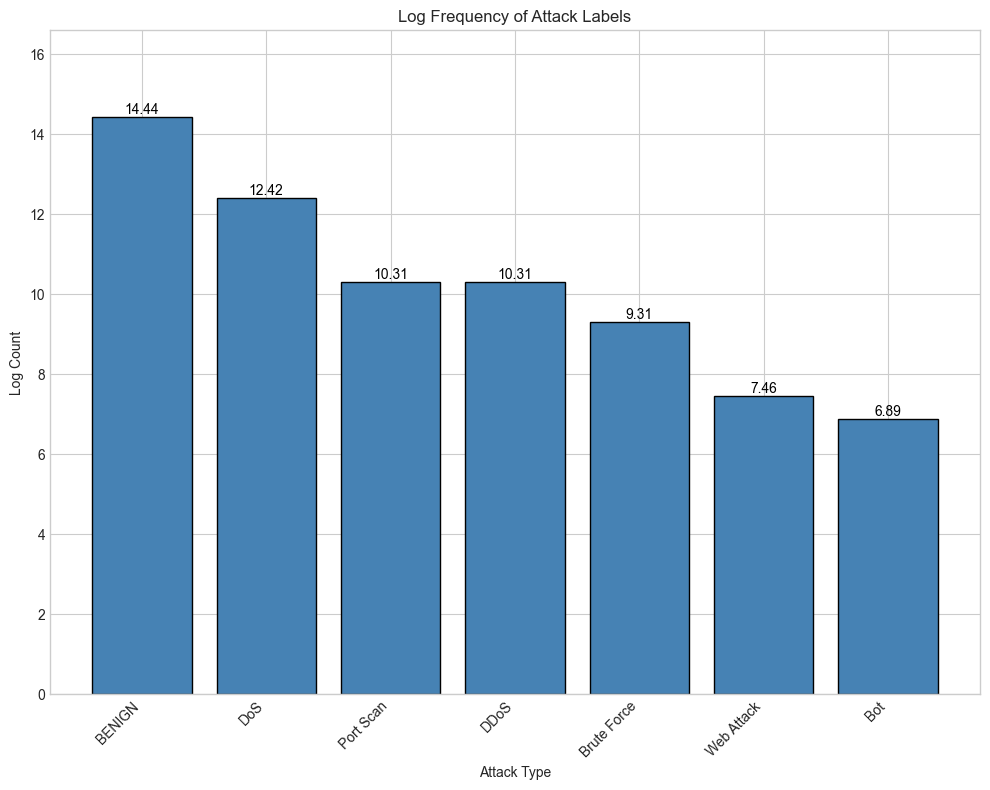

In [174]:
plt.figure(figsize=(10, 8))

bars = plt.bar(
    train_unique_attacks_names,
    np.log(train_unique_attacks),
    color="steelblue",
    edgecolor="black"
)

for bar, value in zip(bars, np.log(train_unique_attacks)):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title("Log Frequency of Attack Labels")
plt.xlabel("Attack Type")
plt.ylabel("Log Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
ymax = max(np.log(train_unique_attacks))
plt.ylim(0, ymax * 1.15) 
plt.show()

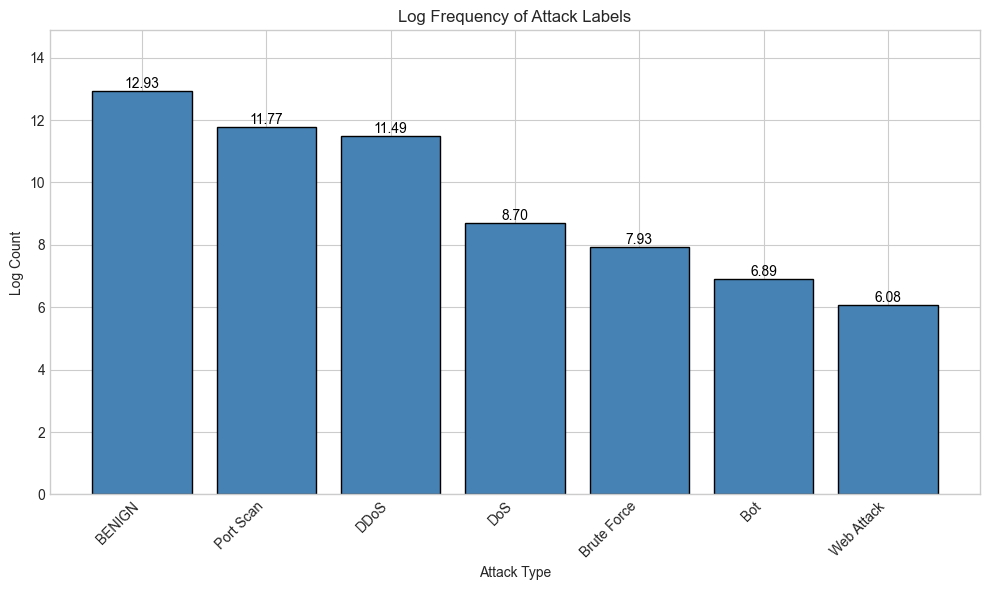

In [175]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    test_unique_attacks_names,
    np.log(test_unique_attacks),
    color="steelblue",
    edgecolor="black"
)

for bar, value in zip(bars, np.log(test_unique_attacks)):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title("Log Frequency of Attack Labels")
plt.xlabel("Attack Type")
plt.ylabel("Log Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
ymax = max(np.log(test_unique_attacks))
plt.ylim(0, ymax * 1.15) 
plt.show()

Removing Duplicates

In [176]:
dups_train = merged_df_train[merged_df_train.duplicated()]
print(f"Number of Train Duplicates: {len(dups_train)}")
dups_test = merged_df_test[merged_df_test.duplicated()]
print(f"Number of Test Duplicates: {len(dups_test)}")

Number of Train Duplicates: 203521
Number of Test Duplicates: 70723


In [186]:
total_train = merged_df_train.shape[0]
unique_count_train = total_train - len(dups_train)
total_test = merged_df_test.shape[0]
unique_count_test = total_test - len(dups_test)
labels = ["Unique Rows", "Duplicate Rows"]
values_train = [unique_count_train, len(dups_train)]
values_test = [unique_count_test, len(dups_test)]

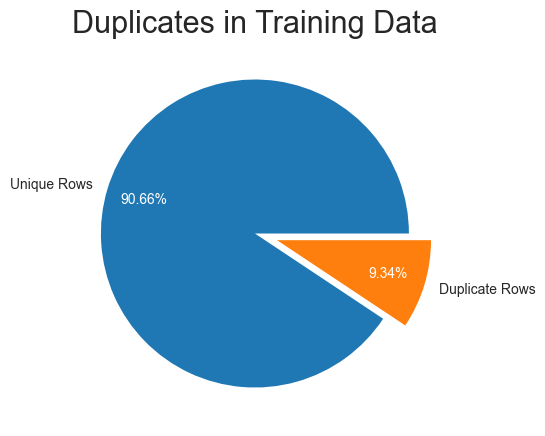

In [187]:
plt.figure(figsize=(5, 5))

plt.pie(
    values_train,
    labels=labels,
    autopct="%1.2f%%",
    explode=[0, 0.15],  # push duplicates outward for emphasis
    pctdistance=0.75,
)
# fix autopct text color (white)
for text in plt.gca().texts:
    if "%" in text.get_text():           # identify only the percentage texts
        text.set_color("white")
plt.title("Duplicates in Training Data", fontsize=22)
plt.show()

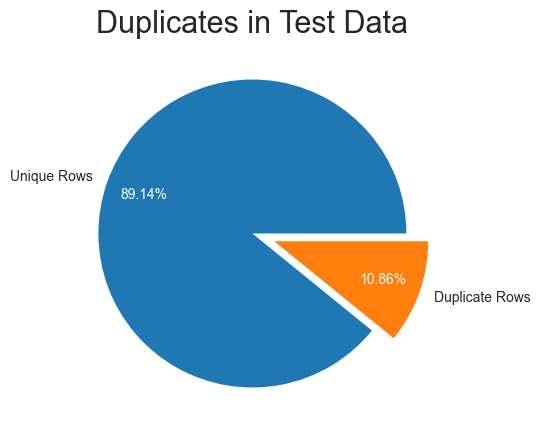

In [188]:
plt.figure(figsize=(5, 5))

plt.pie(
    values_test,
    labels=labels,
    autopct="%1.2f%%",
    explode=[0, 0.15],  # push duplicates outward for emphasis
    pctdistance=0.75,
)
# fix autopct text color (white)
for text in plt.gca().texts:
    if "%" in text.get_text():           # identify only the percentage texts
        text.set_color("white")
plt.title("Duplicates in Test Data", fontsize=22)
plt.show()

In [189]:
print(f"Train shape before dropping Duplicates: {merged_df_train.shape}")
train_size = len(merged_df_train)
merged_df_train.drop_duplicates(inplace=True)
train_size_after = len(merged_df_train)
print(f"Train shape after dropping Duplicates: {merged_df_train.shape}")
print(f"Test shape before dropping Duplicates: {merged_df_test.shape}")
test_size = len(merged_df_test)
merged_df_test.drop_duplicates(inplace=True)
test_size_after = len(merged_df_test)
print(f"Test shape after dropping Duplicates: {merged_df_test.shape}")

Train shape before dropping Duplicates: (2179231, 80)
Train shape after dropping Duplicates: (1975710, 80)
Test shape before dropping Duplicates: (651465, 80)
Test shape after dropping Duplicates: (580742, 80)


In [213]:
merged_df_train = merged_df_train.reset_index(drop=True)
merged_df_test = merged_df_test.reset_index(drop=True)

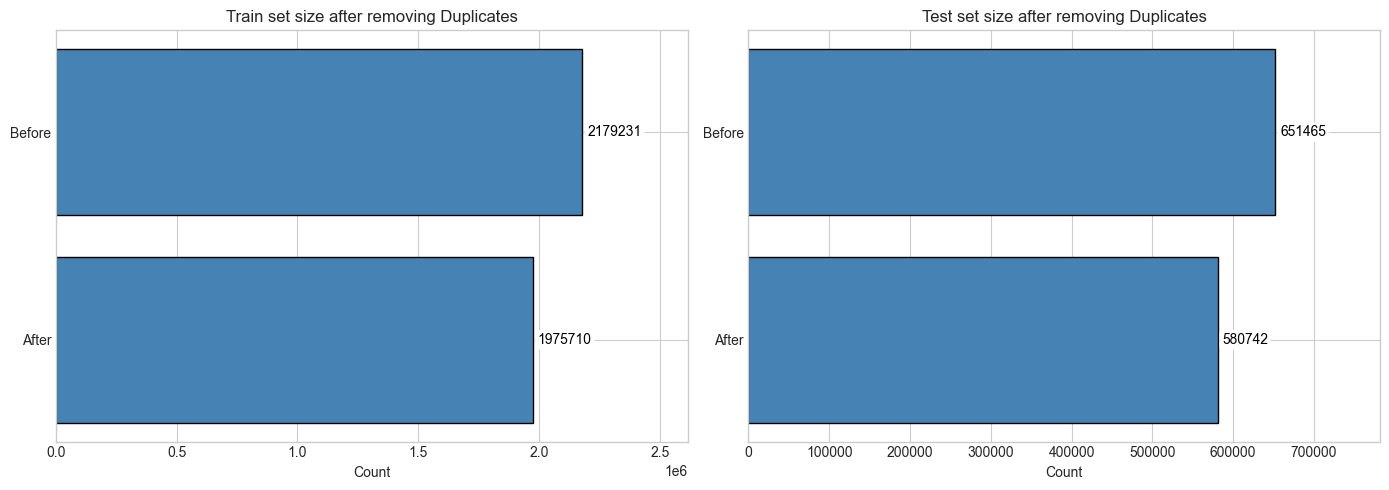

In [214]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- TRAIN ----------------
values_train = [train_size_after, train_size]
labels= ["After", "Before"]

bars = axes[0].barh(labels, values_train, color="steelblue", edgecolor="black")

for bar, v in zip(bars, values_train):
    axes[0].text(
        v * 1.01,
        bar.get_y() + bar.get_height() / 2,
        str(v),
        ha="left",
        va="center",
        fontsize=10,
        color="black",
        bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2")
    )

axes[0].set_title("Train set size after removing Duplicates")
axes[0].set_xlabel("Count")
axes[0].set_xlim(0, max(values_train) * 1.2)


# ---------------- TEST ----------------
values_test = [test_size_after, test_size]

bars = axes[1].barh(labels, values_test, color="steelblue", edgecolor="black")

for bar, v in zip(bars, values_test):
    axes[1].text(
        v * 1.01,
        bar.get_y() + bar.get_height() / 2,
        str(v),
        ha="left",
        va="center",
        fontsize=10,
        color="black",
        bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2")
    )

axes[1].set_title("Test set size after removing Duplicates")
axes[1].set_xlabel("Count")
axes[1].set_xlim(0, max(values_test) * 1.2)

plt.tight_layout()
plt.show()


In [215]:
merged_df_train['Attack'].value_counts()

Attack
BENIGN         1720966
DoS             189135
DDoS             29999
Port Scan        25501
Brute Force       7417
Web Attack        1718
Bot                974
Name: count, dtype: int64

In [216]:
merged_df_test['Attack'].value_counts()

Attack
BENIGN         395106
DDoS            98022
Port Scan       79290
DoS              4871
Brute Force      2039
Bot               981
Web Attack        433
Name: count, dtype: int64

Handling missing and infinity

In [217]:
missing_val_train = merged_df_train.isna().sum()
print("Train:")
print(missing_val_train.loc[missing_val_train > 0])

missing_val_test = merged_df_test.isna().sum()
print("Test:")
print(missing_val_test.loc[missing_val_test > 0])

Train:
Flow Bytes/s    307
dtype: int64
Test:
Flow Bytes/s    50
dtype: int64


In [218]:
merged_df_train.columns[merged_df_train.columns.duplicated()]


Index([], dtype='object')

In [225]:
# Checking for infinity values
numeric_cols = merged_df_train.select_dtypes(include = np.number).columns
inf_count = np.isinf(merged_df_train[numeric_cols]).sum()
print("Train Inf Values")
print(inf_count[inf_count > 0])

numeric_cols = merged_df_test.select_dtypes(include = np.number).columns
inf_count = np.isinf(merged_df_test[numeric_cols]).sum()
print("Test Inf Values")
print(inf_count[inf_count > 0])

Train Inf Values
Flow Bytes/s       834
Flow Packets/s    1141
dtype: int64
Test Inf Values
Flow Bytes/s      393
Flow Packets/s    443
dtype: int64


In [226]:
# Replacing any infinite values (positive or negative) with NaN (not a number)
print(f'Initial missing values Train: {merged_df_train.isna().sum().sum()}')

merged_df_train.replace([np.inf, -np.inf], np.nan, inplace = True)

print(f'Missing values after processing infinite values for Train: {merged_df_train.isna().sum().sum()}')

print(f'Initial missing values Train: {merged_df_test.isna().sum().sum()}')

merged_df_test.replace([np.inf, -np.inf], np.nan, inplace = True)

print(f'Missing values after processing infinite values for Train: {merged_df_test.isna().sum().sum()}')
     

Initial missing values Train: 307
Missing values after processing infinite values for Train: 2282
Initial missing values Train: 50
Missing values after processing infinite values for Train: 886


In [227]:

missing_train = merged_df_train.isna().sum()
print("Train:")
print(missing_train.loc[missing_train > 0])

missing_test = merged_df_test.isna().sum()
print("Test:")
print(missing_test.loc[missing_test > 0])

Train:
Flow Bytes/s      1141
Flow Packets/s    1141
dtype: int64
Test:
Flow Bytes/s      443
Flow Packets/s    443
dtype: int64


In [228]:

# Calculating missing value percentage in the dataset
mis_per = (missing_train / len(merged_df_train)) * 100
mis_table = pd.concat([missing_train, mis_per.round(2)], axis = 1)
print("Train:")
mis_table = mis_table.rename(columns = {0 : 'Missing Values', 1 : 'Percentage of Total Values'})
print(mis_table.loc[mis_per > 0])

mis_per = (missing_test / len(merged_df_test)) * 100
mis_table = pd.concat([missing_test, mis_per.round(2)], axis = 1)
print("\n\nTest:")
mis_table = mis_table.rename(columns = {0 : 'Missing Values', 1 : 'Percentage of Total Values'})
print(mis_table.loc[mis_per > 0])

Train:
                Missing Values  Percentage of Total Values
Flow Bytes/s              1141                        0.06
Flow Packets/s            1141                        0.06


Test:
                Missing Values  Percentage of Total Values
Flow Bytes/s               443                        0.08
Flow Packets/s             443                        0.08


c:\Users\mohak\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


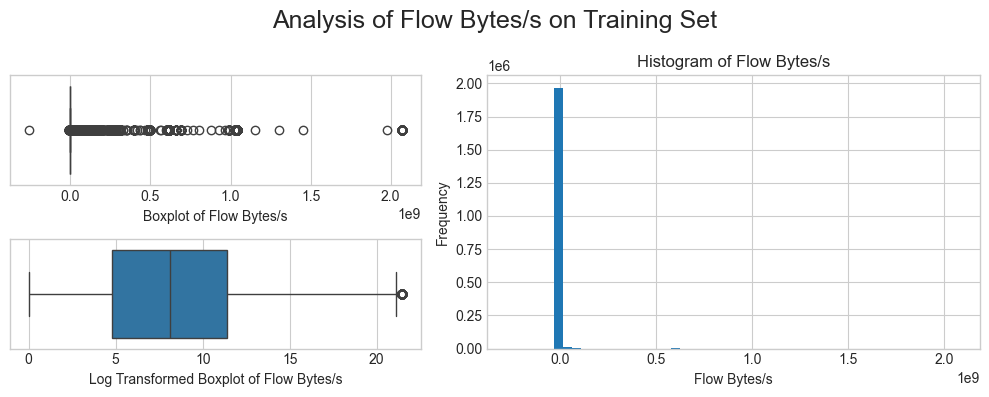

In [239]:
fig = plt.figure(figsize=(10, 4))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.2], height_ratios=[1, 1])

# -------- BOX PLOT 1 (top-left) --------
ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(x=merged_df_train['Flow Bytes/s'], ax=ax1)
ax1.set_xlabel('Boxplot of Flow Bytes/s')

# -------- BOX PLOT 2 (bottom-left) --------
ax2 = fig.add_subplot(gs[1, 0])
sns.boxplot(x=np.log1p(merged_df_train['Flow Bytes/s']), ax=ax2)
ax2.set_xlabel('Log Transformed Boxplot of Flow Bytes/s')

# -------- HISTOGRAM (right column spanning both rows) --------
ax3 = fig.add_subplot(gs[:, 1])
ax3.hist(merged_df_train['Flow Bytes/s'], bins=50)
ax3.set_title('Histogram of Flow Bytes/s')
ax3.set_xlabel('Flow Bytes/s')
ax3.set_ylabel('Frequency')

fig.suptitle("Analysis of Flow Bytes/s on Training Set", fontsize=18)
plt.tight_layout()

plt.show()

c:\Users\mohak\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


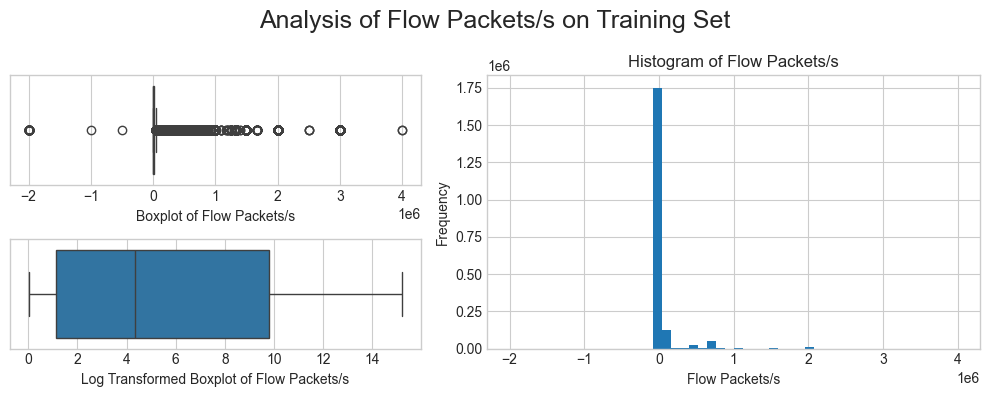

In [240]:
fig = plt.figure(figsize=(10, 4))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.2], height_ratios=[1, 1])

# -------- BOX PLOT 1 (top-left) --------
ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(x=merged_df_train['Flow Packets/s'], ax=ax1)
ax1.set_xlabel('Boxplot of Flow Packets/s')

# -------- BOX PLOT 2 (bottom-left) --------
ax2 = fig.add_subplot(gs[1, 0])
sns.boxplot(x=np.log1p(merged_df_train['Flow Packets/s']), ax=ax2)
ax2.set_xlabel('Log Transformed Boxplot of Flow Packets/s')

# -------- HISTOGRAM (right column spanning both rows) --------
ax3 = fig.add_subplot(gs[:, 1])
ax3.hist(merged_df_train['Flow Packets/s'], bins=50)
ax3.set_title('Histogram of Flow Packets/s')
ax3.set_xlabel('Flow Packets/s')
ax3.set_ylabel('Frequency')

fig.suptitle("Analysis of Flow Packets/s on Training Set", fontsize=18)
plt.tight_layout()

plt.show()

c:\Users\mohak\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


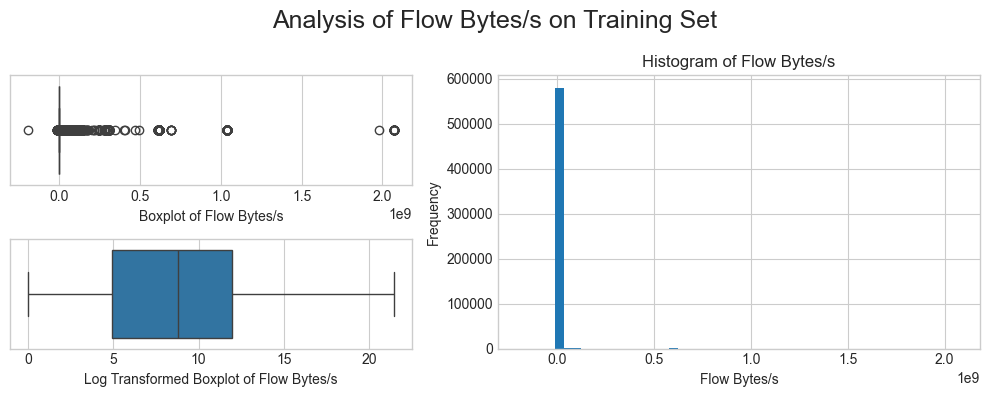

In [ ]:
fig = plt.figure(figsize=(10, 4))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.2], height_ratios=[1, 1])

# -------- BOX PLOT 1 (top-left) --------
ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(x=merged_df_test['Flow Bytes/s'], ax=ax1)
ax1.set_xlabel('Boxplot of Flow Bytes/s')

# -------- BOX PLOT 2 (bottom-left) --------
ax2 = fig.add_subplot(gs[1, 0])
sns.boxplot(x=np.log1p(merged_df_test['Flow Bytes/s']), ax=ax2)
ax2.set_xlabel('Log Transformed Boxplot of Flow Bytes/s')

# -------- HISTOGRAM (right column spanning both rows) --------
ax3 = fig.add_subplot(gs[:, 1])
ax3.hist(merged_df_test['Flow Bytes/s'], bins=50)
ax3.set_title('Histogram of Flow Bytes/s')
ax3.set_xlabel('Flow Bytes/s')
ax3.set_ylabel('Frequency')

fig.suptitle("Analysis of Flow Bytes/s on Test Set", fontsize=18)
plt.tight_layout()

plt.show()

c:\Users\mohak\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


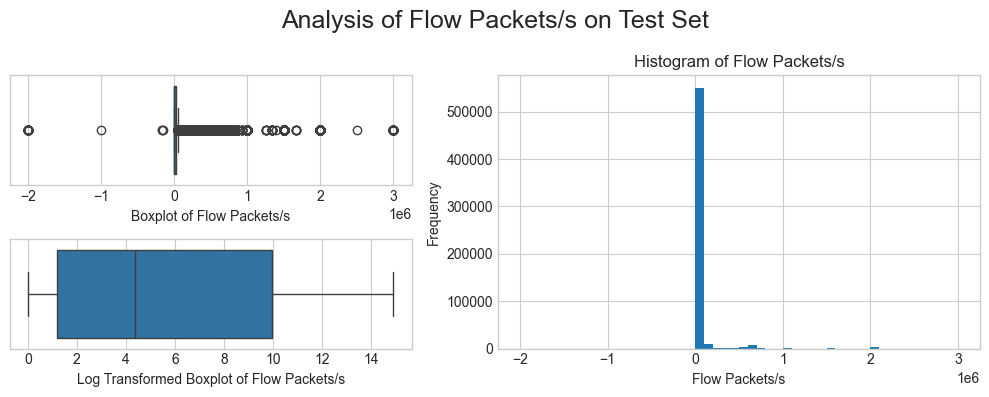

In [242]:
fig = plt.figure(figsize=(10, 4))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1.2], height_ratios=[1, 1])

# -------- BOX PLOT 1 (top-left) --------
ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(x=merged_df_test['Flow Packets/s'], ax=ax1)
ax1.set_xlabel('Boxplot of Flow Packets/s')

# -------- BOX PLOT 2 (bottom-left) --------
ax2 = fig.add_subplot(gs[1, 0])
sns.boxplot(x=np.log1p(merged_df_test['Flow Packets/s']), ax=ax2)
ax2.set_xlabel('Log Transformed Boxplot of Flow Packets/s')

# -------- HISTOGRAM (right column spanning both rows) --------
ax3 = fig.add_subplot(gs[:, 1])
ax3.hist(merged_df_test['Flow Packets/s'], bins=50)
ax3.set_title('Histogram of Flow Packets/s')
ax3.set_xlabel('Flow Packets/s')
ax3.set_ylabel('Frequency')

fig.suptitle("Analysis of Flow Packets/s on Test Set", fontsize=18)
plt.tight_layout()

plt.show()

In [243]:
median_flow_bytes_train = merged_df_train['Flow Bytes/s'].median()
median_flow_packets_train = merged_df_train['Flow Packets/s'].median()

print('Train Median of Flow Bytes/s: ', median_flow_bytes_train)
print('Train Median of Flow Packets/s: ', median_flow_packets_train)

median_flow_bytes_test = merged_df_test['Flow Bytes/s'].median()
median_flow_packets_test = merged_df_test['Flow Packets/s'].median()

print('Train Median of Flow Bytes/s: ', median_flow_bytes_test)
print('Train Median of Flow Packets/s: ', median_flow_packets_test)



Train Median of Flow Bytes/s:  3364.441739
Train Median of Flow Packets/s:  76.670212664
Train Median of Flow Bytes/s:  6644.61771
Train Median of Flow Packets/s:  77.95143626


In [244]:
merged_df_train['Flow Bytes/s'].fillna(median_flow_bytes_train, inplace = True)
merged_df_train['Flow Packets/s'].fillna(median_flow_packets_train, inplace = True)
merged_df_test['Flow Bytes/s'].fillna(median_flow_bytes_test, inplace = True)
merged_df_test['Flow Packets/s'].fillna(median_flow_packets_test, inplace = True)

In [245]:
print('Number of \'Flow Bytes/s\' missing values:', merged_df_train['Flow Bytes/s'].isna().sum())
print('Number of \'Flow Packets/s\' missing values:', merged_df_train['Flow Packets/s'].isna().sum())
print('Number of \'Flow Bytes/s\' missing values:', merged_df_test['Flow Bytes/s'].isna().sum())
print('Number of \'Flow Packets/s\' missing values:', merged_df_test['Flow Packets/s'].isna().sum())

Number of 'Flow Bytes/s' missing values: 0
Number of 'Flow Packets/s' missing values: 0
Number of 'Flow Bytes/s' missing values: 0
Number of 'Flow Packets/s' missing values: 0


In [246]:
merged_df_train['Attack'].value_counts()

Attack
BENIGN         1720966
DoS             189135
DDoS             29999
Port Scan        25501
Brute Force       7417
Web Attack        1718
Bot                974
Name: count, dtype: int64

In [247]:
merged_df_test['Attack'].value_counts()

Attack
BENIGN         395106
DDoS            98022
Port Scan       79290
DoS              4871
Brute Force      2039
Bot               981
Web Attack        433
Name: count, dtype: int64

In [248]:
merged_df_train.drop('Label', axis = 1, inplace = True)
merged_df_test.drop('Label', axis = 1, inplace = True)

In [249]:
merged_df_test.shape

(580742, 79)

In [250]:
merged_df_train.to_parquet('train.parquet')
merged_df_test.to_parquet('test.parquet')